# Real archival pages → OCR → matching

City, year and original source identifiers are concealed; names and original printing are retained. These are real source excerpts and reviewed case judgements. The [outcome branch](https://github.com/ikarurs/synthetic-record-linkage/tree/fictional-outcomes) uses entirely fictional municipal data. Prepared with AI coding assistance for Urs Maier.

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from ocr import ROOT, read_page, PROMPT
from run import run, read_csv
from visualise import pages, comparison, export
%matplotlib inline
pd.set_option('display.max_colwidth', 100)
records, page_audit, anchors, pairs, decisions = run()
records_df = pd.DataFrame(records)
manifest = json.loads((ROOT/'data/manifest.json').read_text())

## 1. An accepted identity judgement

Find **Huber August** under **Fürsorge- und Jugendamt** in the earlier excerpt (right column, lower half). Then find **Aug. Huber** under **Stadtjugendamt** in the later excerpt (right column, near the top). The name order changes, the first name is abbreviated, and the institutional heading changes. The municipal youth-welfare context and rank support the reviewed same-person judgement.

The earlier page also contains **Huber Ludwig** and the later page **Simon Huber**. Surname agreement alone cannot establish identity.

The blue rectangles locate the enlarged details; they are manually reviewed display windows, not OCR detections. The aligned rows show the actual extraction and derived names. [Full earlier excerpt](data/pages/sample-a-before.png) · [Full later excerpt](data/pages/sample-a-after.png).

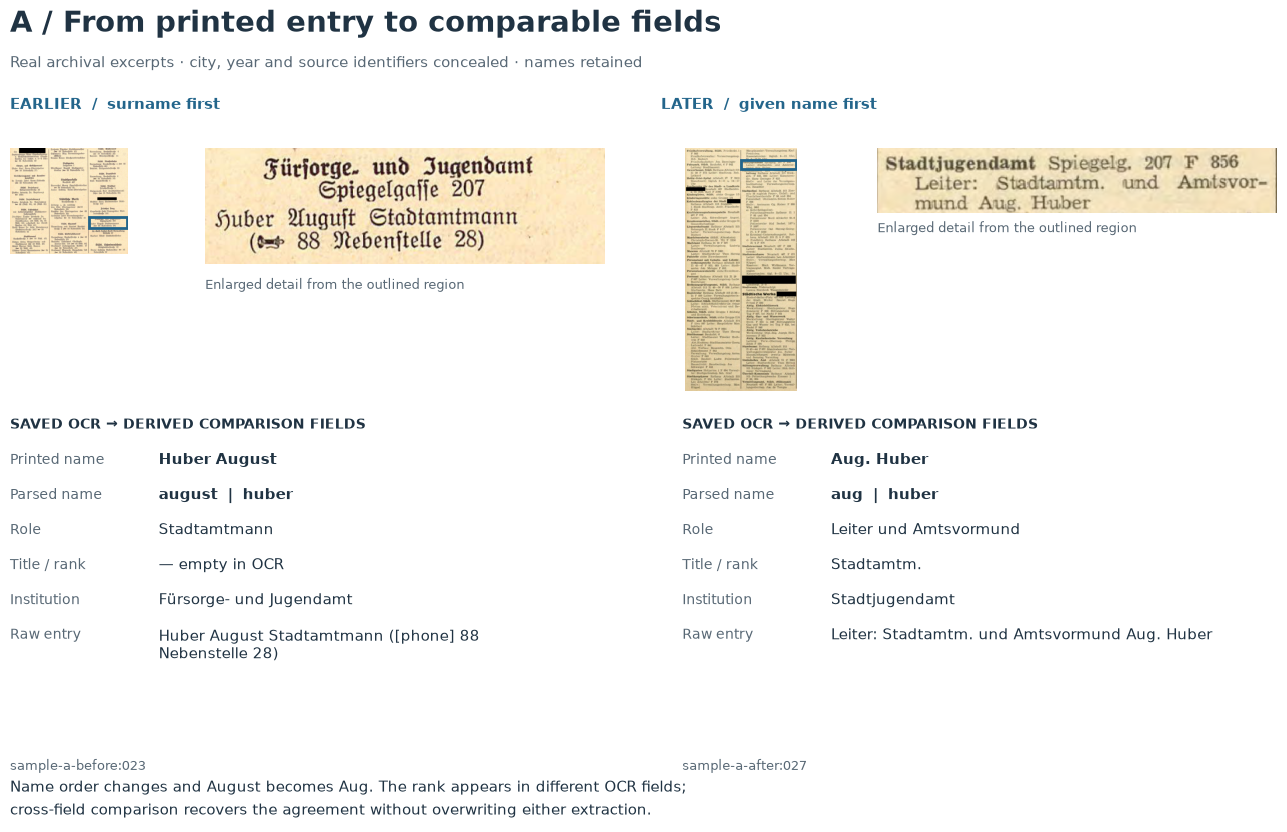

In [2]:
fig = pages('a', records)
export(fig, 'source_a')
display(fig)
plt.close(fig)

## 2. A rejected candidate and a no-observed-match anchor

Find **Eder Rupert** in the earlier excerpt, under the gendarmerie command (left column, near the bottom). The later excerpt contains **Roman Eder**, a district welfare official. The surname agrees; the given names and administrative careers do not. The pair was reviewed as different people.

The original full-roster review found no later match for Rupert Eder. These public excerpts show one rejected candidate; they cannot themselves replicate the full-roster search. Other people on these pages may reappear. No observed match is not proof of dismissal, death, or any specific denazification outcome.

[Full earlier excerpt](data/pages/sample-b-before.png) · [Full later excerpt](data/pages/sample-b-after.png).

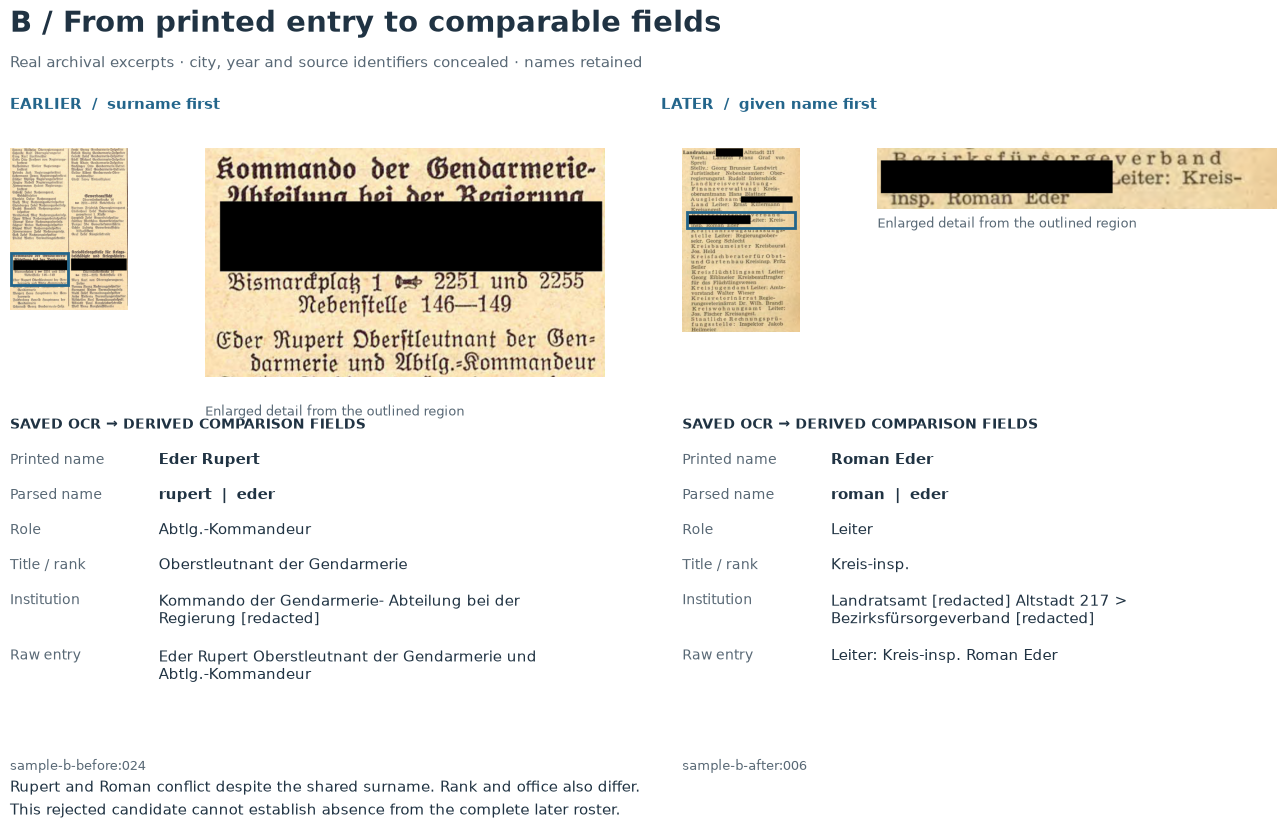

In [3]:
fig = pages('b', records)
export(fig, 'source_b')
display(fig)
plt.close(fig)

## 3. What the OCR receives and returns

Each API call receives **one redacted image**, an extraction prompt and a JSON schema. It receives neither the original PDF/source map nor matching labels or the other period. Hidden text must remain unknown.

`data/ocr/` contains actual Gemini responses. The default run replays them offline after checking image, prompt, schema and configuration hashes. `python ocr.py --live` explicitly makes new API calls. The model's confidence is self-reported, not measured accuracy.

In [4]:
print(PROMPT)
saved = read_page(manifest[0])
display(pd.DataFrame(page_audit)[['page_id', 'people', 'model', 'confidence']])
print('Captured:', saved['captured_utc'])
print('Image SHA-256:', saved['image_sha256'])
# The complete, unedited transcription remains in data/ocr/sample-a-before.json.
print(next(entry['raw_entry'] for entry in saved['page']['entries']
           if entry['name'] == 'Huber August'))

Read this redacted historical German address-book excerpt visually. Return a full plain-text
transcription in reading order, and extract every explicitly named person in an
institutional section. Preserve the printed name, role (function), title (rank or
honorific), address and heading hierarchy separately. Do not expand initials, fix
names, infer identity, or invent missing text. Names after a comma remain as printed.
Addresses, office hours, telephone numbers and unnamed positions are not people.
institution_path lists visible headings from broadest to most specific. Do not add
the page banner to the hierarchy. For entries continuing from the previous page
without a visible institution, set continued=true and institution_path=[]. Do not
invent the previous heading. Record active_hierarchy_at_end for the last section.
Black rectangles conceal identifying source details. Transcribe them as [redacted]
and never infer the city, year, source, or hidden words. A crop may begin mid-section;

,page_id,people,model,confidence
0,sample-a-before,25,gemini-3.5-flash,0.98
1,sample-a-after,46,gemini-3.5-flash,0.98
2,sample-b-before,52,gemini-3.5-flash,0.95
3,sample-b-after,14,gemini-3.5-flash,0.95


Captured: 2026-09-16T14:36:38.073382+00:00
Image SHA-256: 8401ebf06c5a5e7669587c275450740014d599a3246ceb4299e9d5ca624b2ca6
Huber August Stadtamtmann ([phone] 88 Nebenstelle 28)


### From printed entries to structured observations

Preserve the printed name and raw entry separately from derived name components. Roles, ranks and headings span lines; an office can list an address without naming anyone. A crop may start in a continuing section, so missing heading context stays unknown. Birth dates and hidden locality names are never filled in.

An actual extraction inconsistency is visible below: *Stadtamtmann* is placed in the earlier **role** field, while *Stadtamtm.* appears in the later **title** field. Comparing across those fields and normalising the abbreviation preserves the evidence without overwriting the OCR response.

In [5]:
display(records_df.loc[records_df['surname'].isin(['huber', 'eder']),
    ['record_id', 'name', 'given', 'surname', 'role', 'title']])

,record_id,name,given,surname,role,title
15,sample-a-before:016,Huber Ludwig,ludwig,huber,Verw.-Oberinspektor,
22,sample-a-before:023,Huber August,august,huber,Stadtamtmann,
51,sample-a-after:027,Aug. Huber,aug,huber,Leiter und Amtsvormund,Stadtamtm.
54,sample-a-after:030,Simon Huber,simon,huber,Polizeichef,Oberamtm.
94,sample-b-before:024,Eder Rupert,rupert,eder,Abtlg.-Kommandeur,Oberstleutnant der Gendarmerie
128,sample-b-after:006,Roman Eder,roman,eder,Leiter,Kreis-insp.


## 4. Resolve order and generate candidates

The manifest records a visually checked convention: the earlier lists predominantly print surname first; the later lists print given name first. Explicit commas override that convention. This bounded rule is enough for the two anchors; mixed or ambiguous names require richer context. Unrelated compound names have not all been manually validated.

Select the two earlier anchors without loading their outcomes, then search **all later excerpt entries** within the same neutral town. Surname similarity must be at least 0.82. Compatible abbreviations are compared as prefixes; they are not expanded into invented names.

In [6]:
display(pd.DataFrame(anchors)[['case_id','record_id','name','given','surname','institution']])
display(pd.DataFrame(pairs)[['case_id','left_name','right_name','surname_similarity','given_relation','career_similarity','institution_similarity','score']].round(3))

,case_id,record_id,name,given,surname,institution
0,A,sample-a-before:023,Huber August,august,huber,Fürsorge- und Jugendamt
1,B,sample-b-before:024,Eder Rupert,rupert,eder,Kommando der Gendarmerie- Abteilung bei der Regierung [redacted]


,case_id,left_name,right_name,surname_similarity,given_relation,career_similarity,institution_similarity,score
0,A,Huber August,Aug. Huber,1.0,abbreviation,1.000,0.595,0.950
1,A,Huber August,Simon Huber,1.0,conflict,0.400,0.057,0.630
2,B,Eder Rupert,Roman Eder,1.0,conflict,0.273,0.260,0.605


## 5. Trace decisions, then compare the review

The ranking rule is `0.55 surname + 0.25 given + 0.20 max(career, institution)`. It is not a probability or fitted research model. Rank abbreviations are normalised; roles and titles are compared across fields. Conflicting given names reject a pair. Initial-only or missing given names stay uncertain.

Acceptance requires score ≥ 0.84, mutual best choice, margin ≥ 0.08 on both sides and page confidence ≥ 0.8. Ties remain unresolved. A best candidate is a proposal; `right_id` is populated only for accepted links. Load review labels only after these decisions.

In [7]:
display(pd.DataFrame(decisions).round(3))
display(pd.DataFrame(read_csv(ROOT/'outputs/review_comparison.csv'))[['case_id','status','best_candidate','reviewed_decision','review_evidence']])

,case_id,name,status,reason,right_id,best_candidate,score,margin,reverse_margin
0,A,Huber August,accepted,accepted,sample-a-after:027,Aug. Huber,0.950,0.320,0.950
1,B,Eder Rupert,no_link,given_name_conflict,,Roman Eder,0.605,0.605,0.605


,case_id,status,best_candidate,reviewed_decision,review_evidence
0,A,accepted,Aug. Huber,same_person,Compatible abbreviated given name; same surname and municipal youth-welfare context; rank agrees.
1,B,no_link,Roman Eder,different_person,Same surname but conflicting given names and different administrative careers; no match found in...


## 6. Separate evidence, ranking and the decision

Read each row from left to right: the candidate, four comparison measures, then their contributions to the weighted score. The annotated matrix uses a shared 0–1 scale (white = 0, dark blue = 1). The score bar uses only the **stronger** of rank/role and office evidence, so it does not count both twice. Exact values keep the figure readable without colour.

The dashed line is the acceptance floor, not a probability cutoff. Given-name conflicts reject candidates independently of the score. The accepted candidate must also clear the margin and mutual-preference checks. These selected cases cannot estimate population continuity or general matching accuracy.

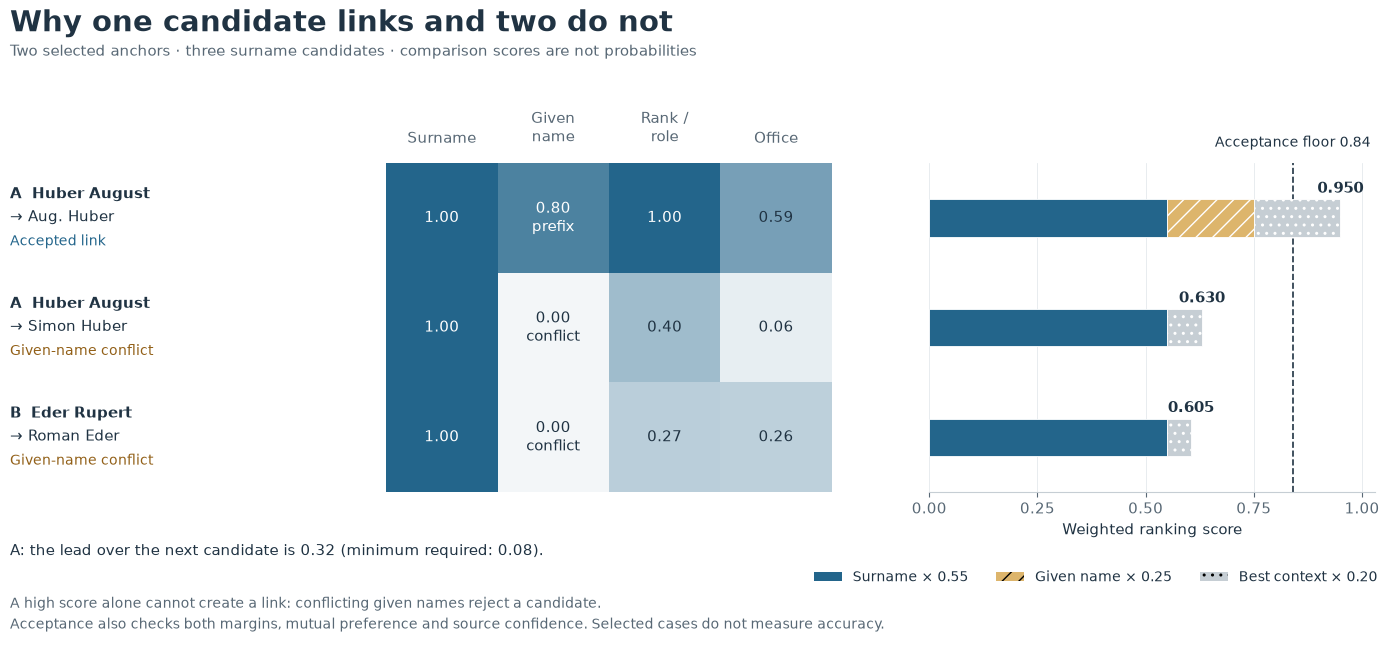

In [8]:
fig = comparison(pairs, decisions)
export(fig, 'evidence')
display(fig)
plt.close(fig)

## 7. Small exercises

1. Trace August Huber from pixels to raw OCR, normalised name, all later surname candidates and the accepted link. What distinguishes him from Simon Huber?
2. Remove the given-name conflict guard in a temporary copy. Explain why surname agreement alone is dangerous for the Eder pair.
3. Compare the OCR transcription with the excerpts. Record uncertain readings without silently replacing raw responses. How might cropping or missing headings affect matching?

The [separate outcome notebook](https://github.com/ikarurs/synthetic-record-linkage/blob/fictional-outcomes/outcomes.ipynb) shows aggregation and housing-construction visualisation with wholly invented towns. It does not attach invented outcomes to this historical town.

### Reuse the figures

Each figure is regenerated from the source images and pipeline rows by the cells above. `visualise.py` contains the plotting code; `outputs/` includes PNG previews and scalable SVG exports. No source pixels or saved OCR responses are modified by the visualisations.